# 🧠 Memory Management in AI, RAG & LangGraph
> **Mastering Short-Term vs. Long-Term Memory, Context Window Optimization, Vector Store RAG Integration, and LangGraph Persistence**

---

## 📌 1. LangChain & LangGraph Memory Abstractions Overview

Memory management is the backbone of production AI agents. LangChain and LangGraph provide several abstractions to maintain context across conversation turns and user sessions:

| Memory Abstraction | Scope | Primary Purpose |
| :--- | :--- | :--- |
| **`ConversationBufferMemory`** | Short-Term / Session | Stores full raw conversation history in memory; passes everything to the model. |
| **`ConversationBufferWindowMemory`** | Short-Term / Session | Keeps a sliding window of the last $K$ turns, discarding older messages to bound token usage. |
| **`ConversationTokenBufferMemory`** | Short-Term / Session | Truncates conversation history based on raw token count limits rather than turn counts. |
| **`ConversationSummaryMemory`** | Short-Term / Session | Continuously updates a running summary of the conversation history via an LLM. |
| **`ConversationSummaryBufferMemory`** | Short-Term / Session | Combines summary and buffer window: keeps recent messages raw while summarizing older turns. |
| **`VectorStoreRetrieverMemory`** | Long-Term / User | Stores memories in a vector index and retrieves relevant historical facts via semantic similarity. |
| **LangGraph `Checkpointer`** | Short-Term / Thread | Persists graph state (`MessagesState`) per `thread_id` so conversations can pause and resume. |
| **LangGraph `Store`** | Long-Term / User | Persists user profiles, preferences, and facts across multiple threads using `namespaces` and `user_id`. |

---

## 🏗️ 2. Memory Architecture Taxonomy

Modern AI Agent architectures divide memory into two fundamental operational tiers:

```
Memory Management Architecture
│
├── ⚡ Short-Term Memory (Session / Thread Scope)
│      │
│      ├── Checkpointer     ──► Persists current thread state (MessagesState) to resume chat
│      ├── Trim             ──► Removes older messages to fit context & cut token costs
│      ├── Delete           ──► Permanently removes specific messages from state
│      ├── Summarize        ──► Compresses lengthy chat history into a concise running summary
│      └── Custom Filtering ──► Applies rule-based filtering on active context window
│
└── 💾 Long-Term Memory (Cross-Session / User Scope)
       │
       ├── Store.put()        ──► Saves user facts, preferences, or profile memories
       ├── Store.get()        ──► Fetches exact saved memory by key / ID
       ├── Store.search()     ──► Queries memories filtered by namespace / user_id
       ├── user_id / namespace──► Isolates memory state per user account or category
       └── Semantic Retrieval ──► Uses vector embeddings to retrieve memories by meaning
```

---

## 📜 3. Quick Reference: Core Operations & Functionality

### ⚡ Short-Term Memory Operations
- **`Checkpointer`**: Saves the current conversation/thread state so the ongoing chat session can be resumed seamlessly.
- **`Trim`**: Truncates older messages and forwards only recent messages to the LLM to minimize token consumption and reduce costs.
- **`Delete`**: Permanently removes targeted messages from the active memory or thread state.
- **`Summarize`**: Condenses long conversation histories into a compact, informative summary.
- **`Custom Filtering`**: Uses custom rule-based logic to specify which messages are retained in the context window.

### 💾 Long-Term Memory Operations
- **`Store.put()`**: Persists user facts, preferences, behavioral profiles, or custom memories across sessions.
- **`Store.get()`**: Fetches an exact saved memory using its unique key or ID.
- **`Store.search()`**: Searches across saved memories, supporting filtering by namespace or user scope.
- **`user_id / namespace`**: Isolates stored memories by individual user accounts, tenants, or categories.
- **`Semantic Retrieval`**: Retrieves memories based on semantic meaning and vector similarity rather than rigid keyword matching.


## 1. Fundamentals: What is Memory in AI?

### ❓ What is Memory in AI?
Memory is the foundational mechanism that enables an AI application to **store, retrieve, and reuse information** across conversation turns. It transforms a stateless Large Language Model (LLM) into an interactive, context-aware assistant capable of personalized, consistent multi-turn conversations.

---

### ⚡ The Problem: LLMs are Stateless
By default, Large Language Models are completely **stateless**. Every API invocation is treated as an isolated, independent event. If past conversation history is not explicitly included in the prompt payload, the model has zero recollection of previous exchanges.

```
Without Memory (Stateless Execution):
┌───────────┐    "My name is Sunny."     ┌───────────┐
│   User    │ ─────────────────────────► │    LLM    │ ──► "Nice to meet you!"
└───────────┘                            └───────────┘
     │                                         ▲
     │          "What is my name?"             │
     └─────────────────────────────────────────┴──► "I'm sorry, I don't know your name."

With Memory (Stateful Context Injection):
┌───────────┐    Previous Context + Query ┌───────────┐
│   User    │ ──────────────────────────► │    LLM    │ ──► "Your name is Sunny!"
└───────────┘                             └───────────┘
```

---

### 💡 Concrete Examples

#### Example 1: User Identity Retention
```
User:  "My name is Sunny."
AI:    "Nice to meet you, Sunny!"
User:  "What is my name?"
AI:    "Your name is Sunny."
```

#### Example 2: Project Context Persistence
```
User:  "I am working on an Agentic RAG system."
...
User:  "What project am I currently working on?"
AI:    "You are working on Agentic RAG!"  (Retrieved via Memory)
```

---

### 🗂️ Two Major Memory Categories

1. **Short-Term Memory**:
   - Focuses on the **current active session or conversation thread**.
   - Manages recent message history, active tool execution results, and temporary state.
   - Typically stored in-memory or in fast key-value caches (e.g., Redis, SQLite checkpointers).

2. **Long-Term Memory**:
   - Persists knowledge **across multiple sessions and long timeframes**.
   - Stores user preferences, behavioral traits, personal facts, and past project details.
   - Managed via databases, vector stores, and structured document stores.

---

### 🎯 Why Memory Management is Essential in Production

- 🔄 **Conversation Continuity**: Maintain multi-turn natural flow and handle complex follow-up questions seamlessly.
- 🎯 **Personalization**: Remember user preferences, technical stack, and personal choices across interactions.
- ⚙️ **Workflow State Tracking**: Track multi-step agentic workflows and multi-tool execution paths.
- 💰 **Token & Cost Optimization**: Prevent context overflow and control expensive token consumption.
- ⚡ **Latency Reduction**: Smaller, targeted prompt payloads lead to faster model generation times.


## 2. Environment Setup & Model Initialization

Before experimenting with memory strategies, we set up our API key environment and initialize the Google Gemini chat model (`google_genai:gemini-3.1-flash-lite`) using LangChain's unified `init_chat_model` abstraction.


In [8]:
import os
from getpass import getpass

if not os.getenv("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass("Enter GOOGLE_API_KEY: ")

print("GOOGLE_API_KEY configured:", bool(os.getenv("GOOGLE_API_KEY")))

GOOGLE_API_KEY configured: True


In [9]:
from langchain.chat_models import init_chat_model

In [10]:
model = init_chat_model("google_genai:gemini-3.1-flash-lite")

In [11]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}])

AIMessage(content=[{'type': 'text', 'text': "I'm doing well, thank you for asking! How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIPCNQnj88xnzN/FGnsIca85Ls7tXMl/UiRObthr14a2Km/WEM+dUI1D/CzzBeIGv1Uz6RkyRyZVSegU2byVWHXpPZlwQBkdMTxhZOd7SkNOLROgCXBW9EXw/JmtrR90nFceUpPESUoxX7hLQ=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a09b14-fb04-7502-a6d7-973c3a3827db-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 26, 'total_tokens': 33, 'input_token_details': {'cache_read': 0}})

## 3. Naive Memory: Unbounded Conversation Buffer

In this initial approach, we store **every single message** sequentially in a raw Python list (`memory = []`). On each user turn, the entire message history is passed directly into `model.invoke()`.


In [6]:
memory = []

In [7]:
def chat(user_input:str)-> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    
    response = model.invoke(memory)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]
    
    memory.append(
        {
            "role": "assistant",
            "content": content
        }
    )
    return content


In [8]:
def run_chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit",}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:", answer)

In [9]:
run_chat_loop()

Type 'exit' or 'quit' to stop.

AI: [{'type': 'text', 'text': 'Hello, Areeb! It’s a pleasure to meet you. I am doing very well, thank you for asking! How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EnEKbwERTTIPPIHzXRuw/Cj4JQNfrVNJIxJYAG/svigYcfH09mbhJcU+KzsTZIPEqT672p9oH8EsD4jx2+6ujFBOR51ddUQXn0N66VwfsWOsPrM1kenjym/gxCrjrU2m1L8Vty+4s+gk6Rfr0zKqhpUgJg=='}}]

AI: [{'type': 'text', 'text': 'I would love to! Football (or soccer, depending on where you are!) is a massive topic with so much to talk about.\n\nTo get us started, what kind of football fan are you? Here are a few ways we could dive in:\n\n*   **The Professional Leagues:** Do you follow the Premier League, La Liga, Champions League, or maybe somewhere else?\n*   **Player Debates:** Who do you think is the G.O.A.T. (Greatest of All Time)? Or who is currently the best player in the world?\n*   **Tactics and Strategy:** Are you interested in how certain managers set up their teams, like Pep

In [10]:
memory

[{'role': 'user', 'content': 'Hello, how are you? My name is Areeb'},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'Hello, Areeb! It’s a pleasure to meet you. I am doing very well, thank you for asking! How are you doing today? Is there anything I can help you with?',
    'extras': {'signature': 'EnEKbwERTTIPPIHzXRuw/Cj4JQNfrVNJIxJYAG/svigYcfH09mbhJcU+KzsTZIPEqT672p9oH8EsD4jx2+6ujFBOR51ddUQXn0N66VwfsWOsPrM1kenjym/gxCrjrU2m1L8Vty+4s+gk6Rfr0zKqhpUgJg=='}}]},
 {'role': 'user', 'content': 'Can we discuss about football'},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': 'I would love to! Football (or soccer, depending on where you are!) is a massive topic with so much to talk about.\n\nTo get us started, what kind of football fan are you? Here are a few ways we could dive in:\n\n*   **The Professional Leagues:** Do you follow the Premier League, La Liga, Champions League, or maybe somewhere else?\n*   **Player Debates:** Who do you think is the G.O.A.T

In [11]:
for message in memory:
        print(message["role"], "->", message["content"])

user -> Hello, how are you? My name is Areeb
assistant -> [{'type': 'text', 'text': 'Hello, Areeb! It’s a pleasure to meet you. I am doing very well, thank you for asking! How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EnEKbwERTTIPPIHzXRuw/Cj4JQNfrVNJIxJYAG/svigYcfH09mbhJcU+KzsTZIPEqT672p9oH8EsD4jx2+6ujFBOR51ddUQXn0N66VwfsWOsPrM1kenjym/gxCrjrU2m1L8Vty+4s+gk6Rfr0zKqhpUgJg=='}}]
user -> Can we discuss about football
assistant -> [{'type': 'text', 'text': 'I would love to! Football (or soccer, depending on where you are!) is a massive topic with so much to talk about.\n\nTo get us started, what kind of football fan are you? Here are a few ways we could dive in:\n\n*   **The Professional Leagues:** Do you follow the Premier League, La Liga, Champions League, or maybe somewhere else?\n*   **Player Debates:** Who do you think is the G.O.A.T. (Greatest of All Time)? Or who is currently the best player in the world?\n*   **Tactics and Strategy:** Are

### ⚠️ Bottlenecks of Unbounded Memory (The Full History Trap)

While passing full history is simple, it quickly breaks down as conversations grow longer:

- 📈 **Exponential Token Growth**: Every new turn sends all prior messages again, leading to quadratic token consumption.
- 💸 **Escalating Costs**: API billing scales linearly with input token count per request.
- ⏳ **Increased Latency**: Processing larger prompts adds noticeable time-to-first-token delay.
- 💥 **Context Window Limits**: Exceeding model token limits causes API errors (`ContextWindowExceededError`).

> 💡 **Architectural Solution**: We must **decouple what we store** (full audit log) from **what we send to the LLM** (active context payload).


## 4. Strategy 1: Sliding Window Memory (Buffer Window)

### 🪟 How Sliding Window Memory Works
In a **Sliding Window** strategy, we store the full conversation history in long-term storage, but only slice and supply the **most recent $N$ messages** (e.g., last 6 messages) to the LLM active context.

```
Full Stored History (Audit Log):
[ M1 | M2 | M3 | M4 | M5 | M6 | M7 | M8 | M9 | M10 ]
 \________________/   \____________________________/
  Truncated Messages      Active LLM Context Window (Last 6)
```

- 🟢 **Pros**: Extremely fast, simple to implement, keeps token usage strictly bounded.
- 🔴 **Cons**: Discards older context entirely. If the user stated their name in `M1`, the model forgets it by `M7`.


In [12]:
full_history = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "M10"
]

In [13]:
recent_context = full_history[-6:]

In [14]:
recent_context

['M5', 'M6', 'M7', 'M8', 'M9', 'M10']

In [15]:
memory = []

In [16]:
MAX_CONTEXT_MESSAGES = 6

In [17]:
def chat(user_input: str) -> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    recent_context = memory[-MAX_CONTEXT_MESSAGES:]
    
    response = model.invoke(recent_context)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]
    memory.append(
        {
            "role": "assistant",
            "content": content
        }
    )
    return content


In [18]:
def run_chat_loop():
    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in {
            "exit",
            "quit",
        }:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:", answer)

        print("\n[Full stored messages]:", len(memory))

        print(
            "[Messages used as active context]:",
            min(
                len(memory),
                MAX_CONTEXT_MESSAGES,
            )
        )

In [19]:
run_chat_loop()

Type 'exit' or 'quit' to stop.

AI: [{'type': 'text', 'text': 'Hi Areeb! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EnEKbwERTTIPbq/qt52Ezm7COQuIiTHW7LT8y9nhtf0D9Vi+mYkE9auc6Jk4xuF9d1R/G2Ee0ZfcQaXt5SALU0oIosXGUk/ffvy7TzPlNmenX6kF3NDwrdUE7VUtk/UpF+i5ZPUeIP1eCY6mSLclUD/EBw=='}}]

[Full stored messages]: 2
[Messages used as active context]: 2

AI: [{'type': 'text', 'text': "That’s awesome, Areeb! Football (or soccer, depending on where you are!) is such a high-energy and exciting sport.\n\nTo get to know your football preferences a bit better:\n\n*   **Do you play as a hobby, or are you on a team?**\n*   **What position do you usually like to play?** (Are you a goal-scorer, a defender, or maybe the goalkeeper?)\n*   **Do you have a favorite professional player or a team that you love to watch?**\n\nI'd love to hear more about your game!", 'extras': {'signature': 'EnEKbwERTTIP4oM6ZCR+J5GYnr4SpO9uec3BF4IvCWfrzl/fM9EEzYmPs

## 5. Strategy 2: Summarization + Recent Messages (Summary Buffer)

### 🧠 How Summary Buffer Memory Works
To solve the context-loss issue of sliding windows, the **Summary Buffer** strategy maintains a hybrid memory payload:
1. **Recent Messages**: Kept verbatim (e.g., last 6 messages) for active conversation turn accuracy.
2. **Conversation Summary**: Older messages are compressed into a concise running summary by an LLM prompt.
3. **Payload Structure**: The LLM receives `SystemMessage(Current Summary)` + `Recent Messages`.

```
User Query ──► Append to Memory ──► Exceeds MAX_RECENT_MESSAGES?
                                           │
                        ┌──────────────────┴──────────────────┐
                        ▼                                     ▼
                      (Yes)                                 (No)
     Slice older messages & invoke LLM              Pass active memory
     to update conversation_summary                      directly
                        │                                     │
                        └──────────────────┬──────────────────┘
                                           ▼
                       System Message: [Current Summary]
                       + Recent Messages (Last N turns)
                                           │
                                           ▼
                                      LLM Response
```

- 🟢 **Pros**: Preserves long-term facts (user name, key decisions, project preferences) indefinitely within a fixed token budget.
- 🟢 **Cons**: Requires periodic summary generation calls to the LLM when pruning older turns.


In [32]:
memory = []

In [33]:
conversation_summary = ""

In [34]:
MAX_RECENT_MESSAGES = 6

In [35]:
full_history = []

In [36]:
def format_messages(messages):
    if not messages:
        return "No recent conversation."

    return "\n".join(
        f"{message['role']}: {message['content']}"
        for message in messages
    )

In [37]:
def create_summary(old_summary: str, old_messages: list) -> str:

    conversation_text = format_messages(old_messages)

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{old_summary or "No previous summary."}

Older conversation messages to merge:
{conversation_text}

Create one concise updated summary.

Preserve useful information such as:
- user name
- preferences
- projects
- decisions
- important facts
- important questions and answers

Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]

    return content.strip()


In [38]:
def compress_memory_into_summary():

    global memory
    global conversation_summary

    if len(memory) <= MAX_RECENT_MESSAGES:
        return

    old_messages = memory[:-MAX_RECENT_MESSAGES]

    memory = memory[-MAX_RECENT_MESSAGES:]

    conversation_summary = create_summary(
        conversation_summary,
        old_messages
    )

In [39]:
def chat(user_input: str) -> str:

    global memory
    global full_history

    user_message = {"role": "user","content": user_input}

    memory.append(user_message)
    full_history.append(user_message)

    messages_for_llm = [{"role": "system", "content": f"""Previous conversation summary:{conversation_summary or "No previous summary."}"""},
                        *memory
                        ]
    
    response = model.invoke(messages_for_llm)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]

    assistant_message = {"role": "assistant","content": content}

    memory.append(assistant_message)
    full_history.append(assistant_message)

    # Compress only after a complete user/assistant turn
    compress_memory_into_summary()

    return content


In [40]:
def chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:",answer)
        print("\n[Recent active messages]:",len(memory))
        print("[Full-history messages]:",len(full_history))

        if conversation_summary:

            print("\n[Current summary]:")
            print(conversation_summary)

In [41]:
chat_loop()

Type 'exit' or 'quit' to stop.

AI: Hello Areeb! It's nice to meet you. How are you doing today? Is there anything I can help you with?

[Recent active messages]: 2
[Full-history messages]: 2

AI: That’s great! Football (or soccer, depending on where you are!) is the most popular sport in the world for a reason—it's incredibly exciting.

To get to know your taste a bit better:

*   **Do you have a favorite team** that you support religiously?
*   **Is there a player you really admire** for their skills or work ethic?
*   **Do you play yourself**, or do you prefer watching matches on TV?
*   **Who is your pick for the GOAT?** (Messi vs. Ronaldo is usually the big debate!)

Let me know!

[Recent active messages]: 4
[Full-history messages]: 4

AI: That’s a classic developer preference! It’s interesting how you moved from football to programming—it sounds like you might be a fan of logic and strategy in both fields.

Choosing **Python over C++** is a very common stance, and there are some 

---


In [14]:
state = {
    "memory": [],
    "summary": "",
    "full_history": []
}

In [15]:
MAX_RECENT_MESSAGES = 6

In [16]:
def create_summary(old_messages):

    conversation_text = "\n".join(
        f"{msg['role']}: {msg['content']}"
        for msg in old_messages
    )

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{state["summary"] or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.
Preserve important facts, preferences, projects and decisions.
Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]
    return content.strip()

In [17]:
def compress_memory():

    if len(state["memory"]) <= MAX_RECENT_MESSAGES:
        return

    # Everything except the latest 6 messages
    old_messages = state["memory"][:-MAX_RECENT_MESSAGES]

    # Keep only latest 6 messages
    state["memory"] = state["memory"][-MAX_RECENT_MESSAGES:]

    # Merge old information into previous summary
    state["summary"] = create_summary(old_messages)

In [18]:
def chat(user_input):

    # -------------------------
    # Store user message
    # -------------------------
    user_message = {
        "role": "user",
        "content": user_input
    }

    state["memory"].append(user_message)
    state["full_history"].append(user_message)

    # -------------------------
    # Send:
    # summary + recent messages
    # -------------------------

    messages = [
        {
            "role": "system",
            "content": f"""
Previous conversation summary:

{state["summary"] or "No previous summary."}
"""
        },
        *state["memory"]
    ]

    response = model.invoke(messages)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]

    # -------------------------
    # Store AI response
    # -------------------------

    assistant_message = {
        "role": "assistant",
        "content": content
    }

    state["memory"].append(assistant_message)
    state["full_history"].append(assistant_message)

    # Compress if memory becomes too large
    compress_memory()
    return content

In [19]:
def chat_loop():

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit", "quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:", answer)
        print("\nRecent messages:", len(state["memory"]))
        print("Full history:", len(state["full_history"]))

        if state["summary"]:
            print("\nCurrent Summary:\n", state["summary"])

In [20]:
chat_loop()


AI: [{'type': 'text', 'text': "Hi Areeb! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIP0Omso70NA/TEOXGclx1meCDT1yet2su/seW+8ectwLcDPm5mMfXl9z6k+/6PluzUyq9yLrvVrzfVdoxz3nGTkcmjCop3rSJic7yvrlE7HdNyUm5xuI5Vv4E33VesFUDO7HwhfcHP1OkN/g=='}}]

Recent messages: 2
Full history: 2
Chat ended.


In [21]:
state

{'memory': [{'role': 'user', 'content': 'Hi I am areeb'},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': "Hi Areeb! It's nice to meet you. How are you doing today? Is there anything I can help you with?",
     'extras': {'signature': 'EnEKbwERTTIP0Omso70NA/TEOXGclx1meCDT1yet2su/seW+8ectwLcDPm5mMfXl9z6k+/6PluzUyq9yLrvVrzfVdoxz3nGTkcmjCop3rSJic7yvrlE7HdNyUm5xuI5Vv4E33VesFUDO7HwhfcHP1OkN/g=='}}]}],
 'summary': '',
 'full_history': [{'role': 'user', 'content': 'Hi I am areeb'},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': "Hi Areeb! It's nice to meet you. How are you doing today? Is there anything I can help you with?",
     'extras': {'signature': 'EnEKbwERTTIP0Omso70NA/TEOXGclx1meCDT1yet2su/seW+8ectwLcDPm5mMfXl9z6k+/6PluzUyq9yLrvVrzfVdoxz3nGTkcmjCop3rSJic7yvrlE7HdNyUm5xuI5Vv4E33VesFUDO7HwhfcHP1OkN/g=='}}]}]}

### 📊 Step-by-Step Memory Execution Trace (M1 – M16)

The table below illustrates how the **Summary Buffer Strategy** processes a multi-turn conversation over 16 turns ($M_1$ through $M_{16}$), showing the exact transition between raw message storage, older message slicing, LLM summarization, and active prompt payload construction:

| Turn Step | Actual Conversation Content | Full Stored History | Messages Sliced for Summary | Generated / Updated Running Summary | Active Context Payload Sent to LLM |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **M1-M2** | **User:** My name is Sunny.<br>**AI:** Nice to meet you, Sunny. | $M_1, M_2$ | *None* | *Empty* | $M_1, M_2$ |
| **M3-M4** | **User:** I live in Bengaluru.<br>**AI:** Got it, you live in Bengaluru. | $M_1, M_2, M_3, M_4$ | *None* | *Empty* | $M_1, M_2, M_3, M_4$ |
| **M5-M6** | **User:** I am learning LangGraph.<br>**AI:** Great, LangGraph is useful for stateful agent workflows. | $M_1, M_2, M_3, M_4, M_5, M_6$ | *None* | *Empty* | $M_1, M_2, M_3, M_4, M_5, M_6$ |
| **M7-M8** | **User:** I am building an Agentic RAG project.<br>**AI:** Nice, that combines retrieval with agentic workflows. | $M_1 \dots M_8$ | $M_1, M_2$ | **Sunny is the user's name.** | Summary + $M_3 \dots M_8$ |
| **M9-M10** | **User:** My preferred programming language is Python.<br>**AI:** Got it, you prefer Python. | $M_1 \dots M_{10}$ | $M_1 \dots M_4$ | **Sunny is the user's name and he lives in Bengaluru.** | Summary + $M_5 \dots M_{10}$ |
| **M11-M12** | **User:** I want to use PostgreSQL for persistence.<br>**AI:** PostgreSQL is a good choice for persistent state and data. | $M_1 \dots M_{12}$ | $M_1 \dots M_6$ | **Sunny is the user's name, lives in Bengaluru, and is learning LangGraph.** | Summary + $M_7 \dots M_{12}$ |
| **M13-M14** | **User:** I prefer concise explanations.<br>**AI:** Understood, I will keep explanations concise. | $M_1 \dots M_{14}$ | $M_1 \dots M_8$ | **Sunny lives in Bengaluru, is learning LangGraph, and is building an Agentic RAG project.** | Summary + $M_9 \dots M_{14}$ |
| **M15-M16** | **User:** What am I currently building?<br>**AI:** You are currently building an Agentic RAG project. | $M_1 \dots M_{16}$ | $M_1 \dots M_{10}$ | **Sunny lives in Bengaluru, is learning LangGraph, is building an Agentic RAG project, and prefers Python.** | Summary + $M_{11} \dots M_{16}$ |


## 6. Integrating Short-Term & Long-Term Memory in RAG Systems

Retrieval-Augmented Generation (RAG) applications often struggle with follow-up queries because standard vector retrievers evaluate incoming questions in isolation. Adding memory enables RAG systems to:
1. Rephrase ambiguous follow-up questions using prior conversation context.
2. Maintain document retrieval relevance across extended Q&A sessions.


In [30]:
import os
from getpass import getpass
import faiss
import numpy as np
from langchain.chat_models import init_chat_model
from sentence_transformers import SentenceTransformer

In [31]:
# ============================================================
# GEMINI SETUP
# ============================================================
api_key = os.getenv("GOOGLE_API_KEY")

if not api_key or api_key == "YOUR_GOOGLE_API_KEY":
    api_key = getpass("Enter GOOGLE_API_KEY: ").strip()
    if not api_key:
        raise ValueError("GOOGLE_API_KEY is required.")
    os.environ["GOOGLE_API_KEY"] = api_key

LLM_MODEL = "google_genai:gemini-3.1-flash-lite"

model = init_chat_model(
    LLM_MODEL,
    temperature=0
)

In [34]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}]).content[0]["text"]

"I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?"

In [35]:
# ============================================================
# EMBEDDING MODEL + FAISS INDEX
# ============================================================
embedder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

dimension = embedder.get_sentence_embedding_dimension()
dimension

384

In [36]:
index = faiss.IndexFlatL2(dimension)

In [37]:
documents = []

In [38]:
# ============================================================
# SHORT-TERM CONVERSATION MEMORY
# ============================================================
memory = []

In [39]:
# ============================================================
# CREATE EMBEDDING
# ============================================================
def embed(text):
    embedding = embedder.encode([text])[0]
    return embedding.astype("float32")

In [40]:
# ============================================================
# ADD DOCUMENT TO VECTOR STORE
# ============================================================
def add_document(text):
    embedding = embed(text)
    index.add(np.array([embedding]))
    documents.append(text)

In [41]:
# ============================================================
# RETRIEVE RELEVANT DOCUMENTS
# ============================================================
def retrieve(query, k=2):

    if not documents:
        return []

    query_embedding = embed(query)

    k = min(k, len(documents))

    distances, ids = index.search(np.array([query_embedding]), k)

    results = []

    for i in ids[0]:

        if i != -1:
            results.append(documents[i])

    return results

In [42]:
# ============================================================
# GENERATE ANSWER
# ============================================================
def generate_answer(
    query,
    retrieved_documents,
    memory
):

    # Convert previous conversation into text
    memory_text = "\n".join(
        f"User: {user_query}\n"
        f"Assistant: {assistant_answer}"
        for user_query, assistant_answer in memory
    )

    if not memory_text:
        memory_text = "No previous conversation."


    # Convert retrieved documents into text
    documents_text = "\n".join(retrieved_documents)

    if not documents_text:
        documents_text = "No relevant documents found."


    # Final prompt
    prompt = f"""
You are a helpful AI assistant.

Previous conversation:
{memory_text}

Relevant documents:
{documents_text}

Current user question:
{query}

Answer the user's question using the relevant documents
and previous conversation when useful.

If the answer is not available in the provided documents,
say that you do not know based on the provided documents.
"""
    # Call LLM
    response = model.invoke(prompt)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]

    return (content.strip())

In [43]:
# ============================================================
# SAMPLE KNOWLEDGE BASE
# ============================================================

# Make this cell safe to run multiple times.
index.reset()
documents.clear()

add_document(
    """
    Paris is the capital and largest city of France. The River Seine flows
    through the city and divides it into the Left Bank and the Right Bank.
    Paris is known for landmarks such as the Eiffel Tower, Notre-Dame
    Cathedral, the Arc de Triomphe, and the Champs-Elysees. It is also an
    important European centre for art, fashion, food, and architecture.
    """
)

add_document(
    """
    The Eiffel Tower is located on the Champ de Mars in Paris. Gustave
    Eiffel's company built it for the 1889 World's Fair. The tower is about
    330 metres tall and has observation levels that provide views across
    the city. Nearby attractions include the River Seine and the Trocadero
    gardens, making this area a popular stop for first-time visitors.
    """
)

add_document(
    """
    The Louvre Museum in Paris is one of the world's largest and most visited
    art museums. It is housed in a former royal palace and is recognized by
    the glass pyramid at its main entrance. Its collection includes the Mona
    Lisa, the Venus de Milo, and works from ancient Egypt, Greece, Rome, and
    later European periods. Visitors often need several hours to explore it.
    """
)

add_document(
    """
    Berlin is the capital and largest city of Germany. Major landmarks include
    the Brandenburg Gate, the Reichstag building, the Berlin Cathedral, and
    Museum Island. The Berlin Wall divided the city during the Cold War until
    1989, and the East Side Gallery now preserves a painted section of it.
    Berlin is especially known for its modern history, museums, and creative
    cultural scene.
    """
)

add_document(
    """
    Munich is the capital of Bavaria in southern Germany. The city is famous
    for Oktoberfest, which is generally held from late September into early
    October. Important places include Marienplatz, the Frauenkirche, the
    English Garden, and the Deutsches Museum. Munich is also a useful base
    for travellers interested in the Bavarian Alps and nearby castles.
    """
)

add_document(
    """
    Paris, Berlin, and Munich offer different travel experiences. Paris is a
    strong choice for classical art, iconic architecture, and French cuisine.
    Berlin is better suited to travellers interested in twentieth-century
    history, museums, and contemporary culture. Munich combines traditional
    Bavarian culture with access to nature and the Alps. High-speed and
    intercity trains connect these cities, although Paris to Berlin is the
    longest of the three main routes.
    """
)

In [44]:
documents

['\n    Paris is the capital and largest city of France. The River Seine flows\n    through the city and divides it into the Left Bank and the Right Bank.\n    Paris is known for landmarks such as the Eiffel Tower, Notre-Dame\n    Cathedral, the Arc de Triomphe, and the Champs-Elysees. It is also an\n    important European centre for art, fashion, food, and architecture.\n    ',
 "\n    The Eiffel Tower is located on the Champ de Mars in Paris. Gustave\n    Eiffel's company built it for the 1889 World's Fair. The tower is about\n    330 metres tall and has observation levels that provide views across\n    the city. Nearby attractions include the River Seine and the Trocadero\n    gardens, making this area a popular stop for first-time visitors.\n    ",
 "\n    The Louvre Museum in Paris is one of the world's largest and most visited\n    art museums. It is housed in a former royal palace and is recognized by\n    the glass pyramid at its main entrance. Its collection includes the Mona\

In [45]:
# ============================================================
# RAG + MEMORY CHAT LOOP
# ============================================================
def chat():
    print("RAG with Memory started.")
    print("Type 'exit' or 'quit' to stop.")

    while True:
        query = input("\nUser: ").strip()

        if query.lower() in {
            "exit",
            "quit"
        }:

            print("Chat ended.")
            break

        if not query:
            continue

        # Step 1: Retrieve relevant documents
        retrieved_docs = retrieve(query, k=3)

        # Step 2: Generate answer using
        # previous memory + retrieved documents + current query
        answer = generate_answer(query, retrieved_docs, memory)

        # Step 3: Store current interaction in memory
        memory.append((query, answer))

        # Step 4: Display answer
        print("\nAssistant:", answer)

        # print("\nRetrieved Documents:")
        # for doc in retrieved_docs:
        #     print("-", doc)

        print("\nMemory Size:", len(memory))

In [46]:
# ============================================================
# RUN APPLICATION
# ============================================================
chat()

RAG with Memory started.
Type 'exit' or 'quit' to stop.

Assistant: Based on the provided documents, the main attractions in Paris include:

*   **Landmarks:** The Eiffel Tower, Notre-Dame Cathedral, the Arc de Triomphe, and the Champs-Elysees.
*   **Museums:** The Louvre Museum, which is known for its glass pyramid entrance and houses famous works such as the *Mona Lisa* and the *Venus de Milo*.
*   **General appeal:** The city is also noted for its classical art, iconic architecture, and French cuisine.

Memory Size: 1

Assistant: Based on the provided documents, here is more information about the Eiffel Tower and its surroundings:

*   **The Eiffel Tower:** Located on the Champ de Mars, the tower was built by Gustave Eiffel's company for the 1889 World's Fair. It stands approximately 330 metres tall and features observation levels that offer views across the city.
*   **Nearby Attractions:** The area around the Eiffel Tower is a popular stop for first-time visitors, with the River S

### ✈️ Sample Questions to Test Geography/Travel RAG with Memory
Ask these questions sequentially in the chat session to test context retention and follow-up resolving capabilities:

1. **"What are the main attractions in Paris?"** *(Establishes city context)*
2. **"Tell me more about the Eiffel Tower and the places located nearby."** *(Follow-up on specific attraction)*
3. **"Which museum in that city contains the Mona Lisa?"** *(Implicit pronoun reference "that city")*
4. **"Compare Berlin and Munich for a traveller."** *(Switches context to Germany)*
5. **"Out of those two German cities, which one should I choose if I want to visit the Alps, and why?"** *(Comparative follow-up referencing previous options)*


In [47]:
# ============================================================
# VIEW CONVERSATION MEMORY
# Run this cell after exiting the chat loop.
# ============================================================
if not memory:
    print("Memory is empty. Ask some questions first.")
else:
    print(f"Total conversation turns: {len(memory)}")

    for turn_number, (question, answer) in enumerate(memory, start=1):
        print(f"\n--- Turn {turn_number} ---")
        print("User:", question)
        print("Assistant:", answer)

Total conversation turns: 4

--- Turn 1 ---
User: What are the main attractions in Paris?
Assistant: Based on the provided documents, the main attractions in Paris include:

*   **Landmarks:** The Eiffel Tower, Notre-Dame Cathedral, the Arc de Triomphe, and the Champs-Elysees.
*   **Museums:** The Louvre Museum, which is known for its glass pyramid entrance and houses famous works such as the *Mona Lisa* and the *Venus de Milo*.
*   **General appeal:** The city is also noted for its classical art, iconic architecture, and French cuisine.

--- Turn 2 ---
User: Tell me more about the Eiffel Tower and the places located nearby.
Assistant: Based on the provided documents, here is more information about the Eiffel Tower and its surroundings:

*   **The Eiffel Tower:** Located on the Champ de Mars, the tower was built by Gustave Eiffel's company for the 1889 World's Fair. It stands approximately 330 metres tall and features observation levels that offer views across the city.
*   **Nearby At

### 🛠️ Production RAG: Summary Buffer Memory (`RAGAssistant` Class)
In this implementation, we encapsulate the RAG pipeline into an object-oriented `RAGAssistant` class. It manages vector retrieval, conversation history, and summary compression within a unified structure.


In [65]:
# ============================================================
# CONVERSATION MEMORY
# Summary + Recent Messages
# ============================================================

class ConversationMemory:

    def __init__(
        self,
        model,
        max_recent_messages=6
    ):

        self.model = model

        self.max_recent_messages = (
            max_recent_messages
        )

        self.memory = []

        self.summary = ""

        self.full_history = []


    # --------------------------------------------------------
    # CREATE / UPDATE SUMMARY
    # --------------------------------------------------------

    def create_summary(
        self,
        old_messages
    ):

        conversation_text = "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in old_messages
        )


        prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{self.summary or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.

Preserve:
- important facts
- user preferences
- projects
- decisions
- important previous context

Ignore:
- greetings
- unnecessary small talk
"""


        response = self.model.invoke(
            prompt
        )


        content = response.content if isinstance(response.content, str) else response.content[0]["text"]
        return content.strip()


    # --------------------------------------------------------
    # COMPRESS MEMORY
    # --------------------------------------------------------

    def compress(self):

        if (
            len(self.memory)
            <= self.max_recent_messages
        ):
            return


        # Everything except latest messages
        old_messages = self.memory[
            :-self.max_recent_messages
        ]


        # Keep latest messages
        self.memory = self.memory[
            -self.max_recent_messages:
        ]


        # Update summary
        self.summary = (
            self.create_summary(
                old_messages
            )
        )


    # --------------------------------------------------------
    # ADD USER MESSAGE
    # --------------------------------------------------------

    def add_user_message(
        self,
        content
    ):

        message = {
            "role": "user",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # ADD ASSISTANT MESSAGE
    # --------------------------------------------------------

    def add_assistant_message(
        self,
        content
    ):

        message = {
            "role": "assistant",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # GET RECENT CONVERSATION
    # --------------------------------------------------------

    def get_recent_conversation(self):

        if not self.memory:
            return "No recent conversation."


        return "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in self.memory
        )

In [ ]:
# ============================================================
# RAG ASSISTANT
# ============================================================

class RAGAssistant:

    def __init__(self, model, retriever, max_recent_messages=6):

        self.model = model
        self.retriever = retriever
        self.memory = ConversationMemory(model=model, max_recent_messages=(max_recent_messages))

    # --------------------------------------------------------
    # QUERY REWRITING
    # --------------------------------------------------------
    def rewrite_query(self,user_query):

        recent_conversation = (self.memory.get_recent_conversation())
        
        prompt = f"""
You rewrite conversational questions into
standalone search queries.

Conversation summary:
{self.memory.summary or "No previous summary."}

Recent conversation:
{recent_conversation}

Current user question:
{user_query}

Rewrite the current question as a complete,
standalone search query.

Return only the rewritten query.
"""
        response = self.model.invoke(prompt)

        content = response.content if isinstance(response.content, str) else response.content[0]["text"]
        return content.strip()

    # --------------------------------------------------------
    # RETRIEVE DOCUMENTS
    # --------------------------------------------------------

    def retrieve_documents(self,query):

        documents = (
            self.retriever.invoke(
                query
            )
        )


        return documents


    # --------------------------------------------------------
    # FORMAT DOCUMENTS
    # --------------------------------------------------------

    def format_documents(self, documents):

        if not documents:
            return "No relevant documents found."

        return "\n\n".join(
            doc.page_content
            for doc in documents
        )


    # --------------------------------------------------------
    # GENERATE FINAL ANSWER
    # --------------------------------------------------------

    def generate_answer(
        self,
        user_query,
        documents
    ):

        document_context = (
            self.format_documents(
                documents
            )
        )


        messages = [

            {
                "role": "system",
                "content": f"""
You are a helpful RAG assistant.

Previous conversation summary:

{self.memory.summary or "No previous summary."}

Use the conversation memory for context
and use the retrieved documents for
factual information.

Retrieved documents:

{document_context}

If the answer is not available in the
retrieved documents, say that you do not
know based on the available documents.
"""

""
            },

{
    "role": "user",
    "content": user_query
},
            *self.memory.memory
        ]


        response = self.model.invoke(
            messages
        )


        content = response.content if isinstance(response.content, str) else response.content[0]["text"]
        return content


    # --------------------------------------------------------
    # COMPLETE RAG PIPELINE
    # --------------------------------------------------------

    def chat(self, user_input):
        # --------------------------------------
        # 1. Store user message
        # --------------------------------------
        self.memory.add_user_message(user_input)

        # --------------------------------------
        # 2. Rewrite conversational query
        # --------------------------------------
        standalone_query = (
            self.rewrite_query(
                user_input
            )
        )


        # --------------------------------------
        # 3. Retrieve relevant documents
        # --------------------------------------
        documents = (
            self.retrieve_documents(
                standalone_query
            )
        )


        # --------------------------------------
        # 4. Generate final answer
        # --------------------------------------
        answer = (
            self.generate_answer(
                standalone_query,
                documents
            )
        )


        # --------------------------------------
        # 5. Store AI response
        # --------------------------------------
        self.memory.add_assistant_message(
            answer
        )


        # --------------------------------------
        # 6. Compress old memory
        # --------------------------------------
        self.memory.compress()


        return {
            "answer": answer,
            "standalone_query": standalone_query,
            "documents": documents
        }

### 📥 Data Ingestion & HR-Policy Indexing
We load corporate HR Policy documentation, convert text into chunked `Document` objects, and store them in a FAISS vector index for semantic retrieval.


In [67]:
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore


# ============================================================
# 1. SAMPLE DOCUMENTS (Data)
# ============================================================

documents = [

    Document(
        page_content="""
        ANNUAL LEAVE POLICY: Confirmed full-time employees receive 20 days of
        paid annual leave during each calendar year. Annual leave becomes
        available after the employee completes probation and is credited on
        a pro-rata basis for employees joining mid-year. Leave requests of
        three or more consecutive working days should normally be submitted
        at least two weeks in advance. A maximum of five unused days may be
        carried into the next calendar year and must be used by March 31.
        """
    ),

    Document(
        page_content="""
        PROBATION POLICY: The standard probation period for a new employee is
        six months from the date of joining. The manager conducts reviews near
        the third and sixth month to discuss performance, attendance, and role
        expectations. If additional evaluation is required, probation may be
        extended once for up to three months with written reasons. Employees
        receive confirmation in writing after successfully completing the
        probation review.
        """
    ),

    Document(
        page_content="""
        SICK LEAVE POLICY: Full-time employees receive 10 paid sick-leave days
        per calendar year. Employees should inform their manager as early as
        possible on the day of absence. A medical certificate is required for
        more than two consecutive working days of sick leave. Unused sick leave
        expires at the end of the year and cannot be carried forward or paid
        out. Extended medical absence is reviewed separately by Human Resources.
        """
    ),

    Document(
        page_content="""
        BUSINESS TRAVEL POLICY: Business travel must be approved by the
        employee's manager before tickets or accommodation are booked. Eligible
        expenses include economy airfare, rail travel, hotels within the city
        limit, local transportation, and reasonable meals. Employees must file
        the reimbursement claim within 30 days after completing the trip and
        attach itemized receipts. Late claims require written approval from the
        department head and may be rejected by Finance.
        """
    ),

    Document(
        page_content="""
        HOME-OFFICE EQUIPMENT POLICY: Remote and hybrid employees may claim up
        to $500 once every three years for approved home-office equipment.
        Eligible purchases include a monitor, keyboard, mouse, headset, desk,
        and ergonomic chair. Employees must obtain manager approval before a
        purchase and submit the receipt through the expense portal. Computers
        are issued separately by the company and are not covered by this
        allowance. Reimbursed equipment remains company property.
        """
    ),

    Document(
        page_content="""
        HYBRID WORK POLICY: Employees assigned to a hybrid role may work remotely
        for up to three days per week. Teams select common office days so that
        meetings and collaborative work can happen in person. Employees must
        remain available during the core collaboration hours of 10:00 AM to
        4:00 PM in their local time zone. Working permanently from another city
        or country requires prior approval from Human Resources and Tax.
        """
    ),

    Document(
        page_content="""
        WORKING HOURS POLICY: A standard full-time workweek consists of 40 hours,
        normally spread across Monday through Friday. Employees may choose their
        start and finish times with manager agreement, provided they attend
        required meetings and remain available during core collaboration hours.
        Overtime should be approved in advance. Employees are expected to record
        working time and absences accurately in the company attendance system.
        """
    ),

    Document(
        page_content="""
        LEARNING AND DEVELOPMENT POLICY: After completing probation, employees
        may use an annual learning budget of up to $1,200 for job-related courses,
        certifications, books, or conferences. The employee must explain how the
        activity supports their current role or development plan and receive
        manager approval before registration. Proof of completion and receipts
        are required for reimbursement. Unused learning budget does not carry
        into the following year.
        """
    ),

    Document(
        page_content="""
        HEALTH INSURANCE POLICY: Company health insurance begins on the employee's
        first day of employment. The standard plan covers the employee, one spouse
        or registered partner, and up to two dependent children. Employees must
        add eligible dependants within 30 days of joining or during the annual
        enrollment window. Optional coverage for parents is available at the
        employee's own cost. Claim procedures and hospital networks are listed
        in the insurer's online portal.
        """
    ),

    Document(
        page_content="""
        PERFORMANCE AND SEPARATION POLICY: Formal performance reviews take place
        twice each year, with a goal-setting review in January and a progress
        review in July. Promotion and bonus decisions consider performance,
        business results, skills, and role availability. An employee resigning
        during probation normally gives 30 days' notice; a confirmed employee
        normally gives 60 days' notice. Human Resources calculates the final
        settlement, including eligible unused annual leave.
        """
    )
]

In [68]:
# ============================================================
# 2. EMBEDDING MODEL
# ============================================================
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

In [69]:
# ============================================================
# 3. VECTOR STORE
# ============================================================
vector_store = InMemoryVectorStore(
    embedding=embeddings
)

# Add documents into vector store
vector_store.add_documents(
    documents
)

['151b852a-fe5d-46d0-9dad-5ae6364c3609',
 'b7854f8e-7c2f-47eb-870e-db523a04d9e7',
 '591b90cb-1d7e-44bb-ae61-aa50d5b07caa',
 '8ce159d0-621b-4f3a-ba1e-8443197dbaa0',
 'eaddcc88-e07b-467b-b94c-6568fc60f5a3',
 'b3afb944-1562-441c-9485-cf4f6d731061',
 '8d4af9f3-85d1-4212-a079-570bd14fc6ee',
 'd86be474-e009-4c6b-948b-80689cd280c0',
 '30517b8f-e3c8-41f1-8264-1cd1701208b9',
 'e0870225-0dc6-4551-b30d-57cb0106e706']

In [70]:
# ============================================================
# 4. CREATE RETRIEVER
# ============================================================
retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [71]:
rag = RAGAssistant(
    model=model,
    retriever=retriever,
    max_recent_messages=6
)

In [72]:
while True:

    user_input = input(
        "\nYou: "
    ).strip()


    if user_input.lower() in {
        "exit",
        "quit"
    }:

        print(
            "Chat ended."
        )

        break


    if not user_input:
        continue


    result = rag.chat(
        user_input
    )


    print(
        "\nStandalone Query:",
        result["standalone_query"]
    )


    print(
        "\nAI:",
        result["answer"]
    )


    print(
        "\nRecent Messages:",
        len(rag.memory.memory)
    )


    print(
        "Full History:",
        len(
            rag.memory.full_history
        )
    )


    if rag.memory.summary:

        print(
            "\nCurrent Summary:\n",
            rag.memory.summary
        )


Standalone Query: What is the annual leave entitlement for confirmed employees and what are the company's carry-forward policies?

AI: Confirmed full-time employees receive 20 days of paid annual leave during each calendar year.

Regarding carry-forward policies, a maximum of five unused annual leave days may be carried into the next calendar year, and these days must be used by March 31.

Recent Messages: 2
Full History: 2

Standalone Query: What is the company's probation period policy and under what circumstances can it be extended?

AI: The standard probation period for a new employee is six months from their date of joining. During this time, the manager will conduct performance reviews near the third and sixth months to discuss performance, attendance, and role expectations.

Regarding extensions, if additional evaluation is required, the probation period may be extended once for up to three months, provided that written reasons for the extension are documented. Employees will r

<!-- HR Policy Test Questions configuration comments -->


### 📋 HR-Policy Q&A Evaluation Suite
Use the following test sequence to verify multi-turn context retention over policy retrieval:

1. **Leave Policy**: *"How many annual leave days do confirmed employees receive, and what are the carry-forward rules?"*
2. **Probation & Extensions**: *"Explain the probation period and when it can be extended."*
3. **Post-Probation Benefits**: *"After completing it, what learning benefit becomes available?"* *(Relies on context of probation completion)*
4. **Expense Comparison**: *"Compare the approval and reimbursement requirements for business travel and home-office equipment."*
5. **Remote Work Policy**: *"If I work in a hybrid role, how many days can I work remotely, and during which hours must I remain available?"*


In [73]:
# ============================================================
# VIEW RAG CONVERSATION MEMORY
# Run this cell after typing exit in the chat loop.
# ============================================================

def show_rag_memory():

    print("\n========== MEMORY SUMMARY ==========")
    print(
        rag.memory.summary
        or "No summary created yet."
    )

    print("\n========== RECENT MEMORY ==========")

    if not rag.memory.memory:
        print("No recent messages stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.memory,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )

    print("\n========== FULL HISTORY ==========")

    if not rag.memory.full_history:
        print("No conversation history stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.full_history,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )

show_rag_memory()


========== MEMORY SUMMARY ==========
**Updated Summary:**

*   **Annual Leave:** Full-time employees receive 20 days per calendar year; a maximum of five unused days may be carried forward, provided they are used by March 31.
*   **Probation:** The standard probation period is six months, with performance reviews at the three- and six-month marks. If necessary, probation may be extended once for up to three months with documented written reasons. Successful completion is confirmed in writing.

========== RECENT MEMORY ==========
1. User: After completing it, what learning benefit becomes available?
2. Assistant: After completing your probation period, you are eligible for an annual learning budget of up to $1,200. 

This budget can be used for job-related courses, certifications, books, or conferences. To access these funds, you must:
*   Explain how the activity supports your current role or development plan.
*   Obtain manager approval before registering for the activity.
*   Provid

## 7. Advanced Memory Management in LangGraph (`InMemoryStore` + Checkpointers)

LangGraph provides native support for stateful multi-agent workflows by decoupling short-term thread state from long-term user memory:

- **Checkpointer (`MemorySaver`)**: Persists thread-specific conversation state (`MessagesState`) indexed by `thread_id`.
- **Long-Term Store (`InMemoryStore`)**: Persists cross-session user facts, goals, and preferences indexed by `user_id` and structured `namespaces`.


In [1]:
from langchain.chat_models import init_chat_model

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.memory import (
    InMemorySaver
)

from langgraph.store.memory import (
    InMemoryStore
)

from langgraph.config import (
    get_store,
    get_config
)

from langmem import (
    create_memory_store_manager
)

In [2]:
# ============================================================
# MODEL
# ============================================================
model = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    temperature=0
)

In [3]:
# ============================================================
# SHORT-TERM MEMORY
# ============================================================
checkpointer = InMemorySaver()

In [4]:
# ============================================================
# LONG-TERM MEMORY
# ============================================================
store = InMemoryStore(
    index={
        "dims": 768,
        "embed": "google_genai:gemini-embedding-001"
    }
)

### 🔍 Semantic Memory Retrieval & Vector Embeddings

When storing long-term memories in a LangGraph `Store`, we configure an embedding model (`text-embedding-3-small` with `dims: 1536`). This enables semantic similarity search over stored memories:

#### How Vector Store Search Works:
1. **Saving**: Memory text (*"User prefers Python for AI development"*) ──► Embedding Model ──► 1536-dimensional vector stored in memory index.
2. **Retrieving**: Incoming query (*"Which programming language do I prefer?"*) ──► Embedding Model ──► Vector similarity search retrieves top matching facts.


```
Memory Text ──► Embedding Model ──► 1536-dim Vector ──► Store.put()
                                                             │
Current Query ──► Embedding Model ──► Vector Search ──► Store.search()
                                                             │
                                                             ▼
                                                 Relevant User Memories
```


In [5]:
# ============================================================
# AUTOMATIC MEMORY MANAGER
# ============================================================

memory_manager = create_memory_store_manager(

    "google_genai:gemini-3.1-flash-lite",

    namespace=(
        "memories",
        "{user_id}"
    ),

    instructions="""
Extract useful long-term information about the user.

Store:
- user preferences
- important personal facts
- goals
- projects
- decisions

Ignore greetings,
temporary questions,
and unnecessary small talk.
"""
)

### 🗂️ Namespaces & Memory Policy Configuration

#### What is a Namespace?
A **namespace** is a hierarchical path tuple used to group and isolate memories inside a Store (similar to directory folders in a file system):

```
users/
└── sunny_123/
    └── memories/
        ├── memory_1 (User prefers Python)
        └── memory_2 (User works on Agentic RAG)
```

```python
# Example Namespace Tuple
namespace = ("memories", "{user_id}")
```

#### Memory Policy Instructions
The `instructions` string passed to `create_memory_store_manager` guides the LLM on what information to extract:
- **Save**: User preferences, technical stack, long-term goals, personal identity details.
- **Ignore**: Casual greetings, temporary questions, small talk.


In [6]:
DEBUG = True

def chatbot(state: MessagesState):

    config = get_config()
    current_store = get_store()

    configurable = config.get("configurable", {})

    user_id = configurable.get("user_id")
    thread_id = configurable.get("thread_id")

    namespace = (
        "memories",
        user_id
    )

    user_query = (
        state["messages"][-1].content
    )


    # ========================================================
    # SEARCH LONG-TERM MEMORY
    # ========================================================

    memories = current_store.search(
        namespace,
        query=user_query,
        limit=5
    )


    memory_text = "\n".join(
        str(memory.value)
        for memory in memories
    )

    if not memory_text:
        memory_text = (
            "No relevant long-term memories."
        )


    # ========================================================
    # DEBUG
    # ========================================================

    if DEBUG:

        print("\n" + "=" * 60)
        print("DEBUG INFO")
        print("=" * 60)

        print("Configurable :", configurable)
        print("User ID      :", user_id)
        print("Thread ID    :", thread_id)
        print("Namespace    :", namespace)
        print("User Query   :", user_query)

        print(
            "Thread Messages:",
            len(state["messages"])
        )

        print("\nCurrent Thread History:")

        for message in state["messages"]:
            print(
                f"- {message.type}: "
                f"{message.content}"
            )


        print(
            "\nRetrieved Memories:",
            len(memories)
        )

        for memory in memories:
            print(
                "-",
                memory.value
            )


        print("\nMemory Context:")
        print(memory_text)


    # ========================================================
    # SYSTEM PROMPT
    # ========================================================

    system_message = {
        "role": "system",
        "content": f"""
You are a helpful AI assistant.

Relevant long-term memories:

{memory_text}

Use these memories only when relevant.
"""
    }


    # ========================================================
    # LLM CALL
    # ========================================================

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    if DEBUG:

        print(
            "\nLLM Response:",
            response.content
        )

        print("=" * 60)


    return {
        "messages": [
            response
        ]
    }

In [7]:
# ============================================================
# MEMORY NODE
# ============================================================
def save_memory(
    state: MessagesState,
    config
):

    memory_manager.invoke(
        {
            "messages": state["messages"]
        },
        config=config
    )

    return {}

In [8]:
# ============================================================
# BUILD GRAPH
# ============================================================
builder = StateGraph(
    MessagesState
)

In [9]:
builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_memory
)

In [10]:
builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)

In [11]:
# ============================================================
# COMPILE
# ============================================================
graph = builder.compile(
    checkpointer=checkpointer,
    store=store
)

### ⚙️ LangGraph Compilation Architecture

```
graph.compile(checkpointer=checkpointer, store=store)
       │
       ├── checkpointer ──► Persists thread state (MessagesState) per thread_id
       │
       └── store        ──► Persists long-term memories across threads per user_id
```

By passing both a `checkpointer` and a `store`, the agent can track local thread conversations while accessing global user preferences across threads.


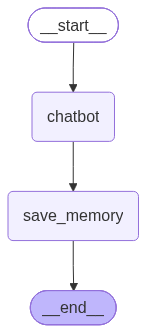

In [12]:
graph

In [13]:
# ============================================================
# CHAT FUNCTION
# ============================================================
def chat(
    user_id,
    thread_id,
    message
):

    config = {
        "configurable": {

            "thread_id": thread_id,

            "user_id": user_id
        }
    }


    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )


    return (
        result["messages"][-1].content[0]["text"]
    )

### 🧵 Thread Isolation: `thread_id` vs. `user_id`  
  
- **`thread_id`**: Identifies a single, specific conversation session (Short-Term Memory).  
- **`user_id`**: Identifies the user account across all past and future sessions (Long-Term Memory).  
  
```  
User: sunny_123  
├── Thread 1 (thread_1): "My favorite language is Python." ──► Stored in Checkpointer & Long-Term Store  
└── Thread 2 (thread_2): "What language do I prefer?"      ──► Retrieves "Python" from Long-Term Store!  
```  

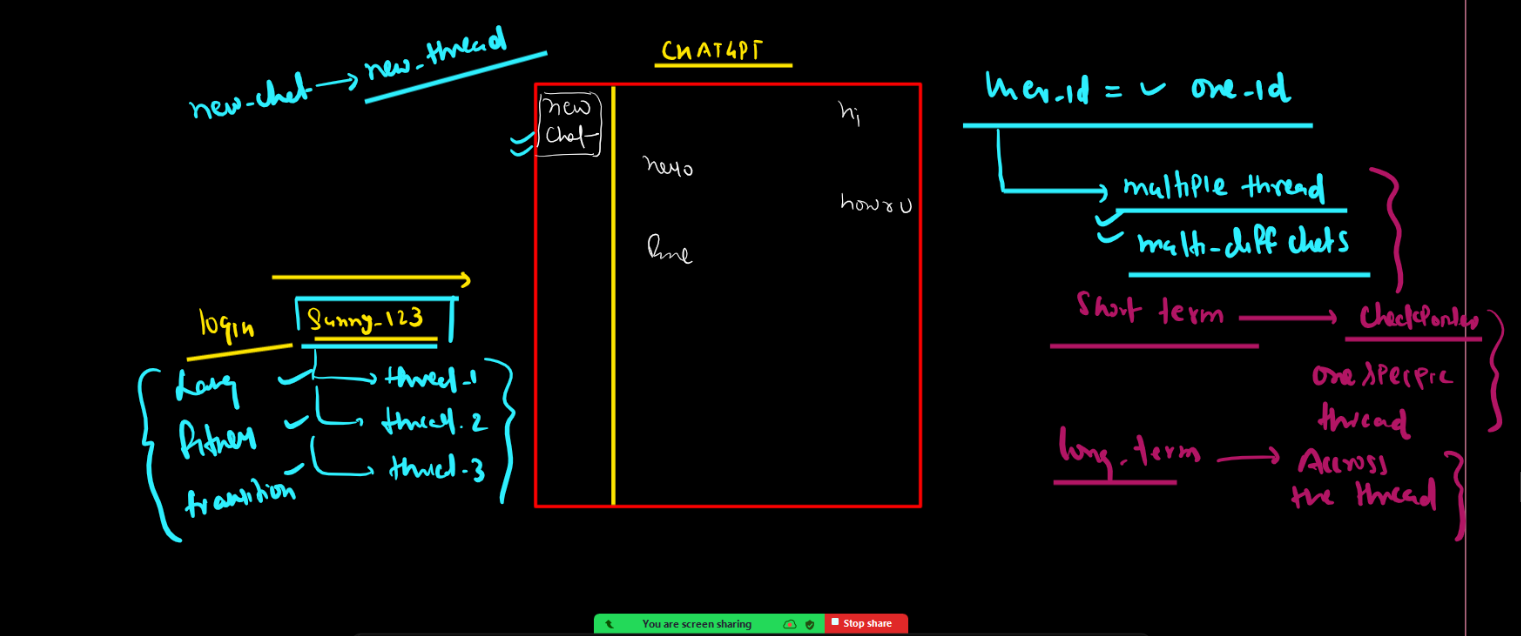

In [14]:
# ============================================================
# TEST + MEMORY VISUALIZATION
# Run this cell immediately after the chat() function cell.
# ============================================================

test_user_id = "sunny_langgraph_test"
thread_1 = "memory_test_thread_1"
thread_2 = "memory_test_thread_2"

In [15]:
# ------------------------------------------------------------
# 1. STORE FACTS IN THREAD 1
# ------------------------------------------------------------
print("\nTEST 1 - Store user information")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "My name is Sunny. I prefer concise explanations, "
            "my favorite language is Python, and I am building "
            "an Agentic RAG project."
        )
    )
)


TEST 1 - Store user information

DEBUG INFO
Configurable : {'thread_id': 'memory_test_thread_1', 'user_id': 'sunny_langgraph_test', '__pregel_runtime': Runtime(context=None, store=<langgraph.store.memory.InMemoryStore object at 0x00000219B8D36750>, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x00000219B8D477E0>, heartbeat=<function _no_op_heartbeat at 0x00000219B66F1260>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1b021b-1e91-6795-8000-a80d39fe4ab0', checkpoint_ns='chatbot:82acba7b-47e2-5fa0-466c-57ea5671d487', task_id='82acba7b-47e2-5fa0-466c-57ea5671d487', thread_id='memory_test_thread_1', run_id=None, node_attempt=1, node_first_attempt_time=1789379419.045457), server_info=None, control=<langgraph.runtime.RunControl object at 0x00000219B8D2BD30>), '__pregel_replay_state': None, '__pregel_task_id': '82acba7b-47e2-5fa0-466c-57ea5671d487', '__pregel_send': <built-in method extend of collections.deque object at 0x00000219B8D12980>, '__pregel_read': 

In [16]:
# ------------------------------------------------------------
# 2. SAME THREAD: TEST SHORT-TERM MEMORY
# ------------------------------------------------------------
print("\nTEST 2 - Same-thread memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "What is my name, which language do I prefer, "
            "and what project am I building?"
        )
    )
)


TEST 2 - Same-thread memory

DEBUG INFO
Configurable : {'thread_id': 'memory_test_thread_1', 'user_id': 'sunny_langgraph_test', '__pregel_runtime': Runtime(context=None, store=<langgraph.store.memory.InMemoryStore object at 0x00000219B8D36750>, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x00000219894FF1A0>, heartbeat=<function _no_op_heartbeat at 0x00000219B66F1260>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1b021b-807b-642d-8004-4bb510ab2ea1', checkpoint_ns='chatbot:ecbf3fd9-ece3-34b4-3213-e7ef450e8368', task_id='ecbf3fd9-ece3-34b4-3213-e7ef450e8368', thread_id='memory_test_thread_1', run_id=None, node_attempt=1, node_first_attempt_time=1789379429.3121605), server_info=None, control=<langgraph.runtime.RunControl object at 0x000002198968C880>), '__pregel_replay_state': None, '__pregel_task_id': 'ecbf3fd9-ece3-34b4-3213-e7ef450e8368', '__pregel_send': <built-in method extend of collections.deque object at 0x00000219B8D136A0>, '__pregel_read': fun

In [17]:
# ------------------------------------------------------------
# 3. NEW THREAD: TEST LONG-TERM MEMORY
# ------------------------------------------------------------
print("\nTEST 3 - Cross-thread long-term memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_2,
        message="What do you remember about me?"
    )
)


TEST 3 - Cross-thread long-term memory

DEBUG INFO
Configurable : {'thread_id': 'memory_test_thread_2', 'user_id': 'sunny_langgraph_test', '__pregel_runtime': Runtime(context=None, store=<langgraph.store.memory.InMemoryStore object at 0x00000219B8D36750>, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x00000219B8DAE2A0>, heartbeat=<function _no_op_heartbeat at 0x00000219B66F1260>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1b021b-d4f1-697f-8000-936b411d70e8', checkpoint_ns='chatbot:dce76365-7d77-8004-5865-e894d1633024', task_id='dce76365-7d77-8004-5865-e894d1633024', thread_id='memory_test_thread_2', run_id=None, node_attempt=1, node_first_attempt_time=1789379438.169445), server_info=None, control=<langgraph.runtime.RunControl object at 0x00000219B8CD12A0>), '__pregel_replay_state': None, '__pregel_task_id': 'dce76365-7d77-8004-5865-e894d1633024', '__pregel_send': <built-in method extend of collections.deque object at 0x00000219B8D127A0>, '__pregel_

Could not apply patch: can't remove a non-existent object ''
Could not apply patch: can't remove a non-existent object ''


Hi Sunny! Here is what I remember:

*   **Name:** Sunny
*   **Favorite Programming Language:** Python
*   **Communication Preference:** You prefer concise explanations.


In [18]:
# ------------------------------------------------------------
# 4. VIEW SHORT-TERM MEMORY FOR A THREAD
# ------------------------------------------------------------
def show_thread_memory(user_id, thread_id):

    config = {
        "configurable": {
            "user_id": user_id,
            "thread_id": thread_id
        }
    }

    snapshot = graph.get_state(config)
    messages = snapshot.values.get("messages", [])

    print("\n" + "=" * 50)
    print(f"SHORT-TERM MEMORY | THREAD: {thread_id}")
    print("=" * 50)

    if not messages:
        print("No messages stored for this thread.")
        return

    for number, message in enumerate(messages, start=1):
        content = message.content if isinstance(message.content, str) else message.content[0]["text"]
        print(
            f"{number}. {message.type.title()}: "
            f"{content}"
        )

In [19]:
# ------------------------------------------------------------
# 5. VIEW LONG-TERM MEMORY FOR A USER
# ------------------------------------------------------------

def show_long_term_memory(user_id):

    memories = store.search(
        ("memories", user_id),
        limit=100
    )

    print("\n" + "=" * 50)
    print(f"LONG-TERM MEMORY | USER: {user_id}")
    print("=" * 50)

    if not memories:
        print("No long-term memories stored for this user.")
        return

    for number, memory in enumerate(memories, start=1):
        print(f"{number}. {memory.value}")

In [20]:
# Display both thread histories and extracted user memories.
show_thread_memory(test_user_id, thread_1)


SHORT-TERM MEMORY | THREAD: memory_test_thread_1
1. Human: My name is Sunny. I prefer concise explanations, my favorite language is Python, and I am building an Agentic RAG project.
2. Ai: Hello, Sunny! It’s great to meet you.

I’ve noted your preferences: concise explanations, Python as your primary language, and your focus on Agentic RAG.

How can I help you with your project today? Are you working on tool calling, planning, or perhaps retrieval strategies?
3. Human: What is my name, which language do I prefer, and what project am I building?
4. Ai: Your name is Sunny, your favorite language is Python, and you are building an Agentic RAG project.


In [21]:
show_thread_memory(test_user_id, thread_2)


SHORT-TERM MEMORY | THREAD: memory_test_thread_2
1. Human: What do you remember about me?
2. Ai: Hi Sunny! Here is what I remember:

*   **Name:** Sunny
*   **Favorite Programming Language:** Python
*   **Communication Preference:** You prefer concise explanations.


In [22]:
show_long_term_memory(test_user_id)


LONG-TERM MEMORY | USER: sunny_langgraph_test
1. {'kind': 'Memory', 'content': {'content': "The user's name is Sunny."}}
2. {'kind': 'Memory', 'content': {'content': 'The user prefers concise explanations.'}}
3. {'kind': 'Memory', 'content': {'content': 'The user is currently building an Agentic RAG project.'}}
4. {'kind': 'Memory', 'content': {'content': "The user's favorite programming language is Python."}}
5. {'kind': 'Memory', 'content': {'content': "The user's name is Sunny."}}
6. {'kind': 'Memory', 'content': {'content': 'The user is currently building an Agentic RAG project.'}}
7. {'kind': 'Memory', 'content': {'content': "The user's favorite programming language is Python."}}
8. {'kind': 'Memory', 'content': {'content': 'The user prefers concise explanations.'}}


## 8. Production Persistence: LangGraph with SQLite Checkpointers & Custom Storage

In production systems, memory must survive application restarts and server crashes. This implementation uses two persistent storage backends:

1. **Short-Term Memory**: `LangGraph SqliteSaver` (Persists graph state per `thread_id` in SQLite database).
2. **Long-Term Memory**: Custom SQLite Storage (`SQLiteLongTermMemory`) (Persists structured user memories per `user_id`).


### 🧱 Dual-Layer SQLite Storage Architecture

- **Short-Term Memory Layer**:
  - Powered by `LangGraph SqliteSaver`.
  - Keyed by `thread_id`.
  - Stores current conversation turn state (`MessagesState`).

- **Long-Term Memory Layer**:
  - Powered by `SQLiteLongTermMemory` database class.
  - Keyed by `user_id`.
  - Stores extracted user facts, preferences, and project goals across sessions.


In [23]:
import sqlite3
import uuid

from typing import List
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.sqlite import (
    SqliteSaver
)

In [24]:
# ============================================================
# MODEL
# ============================================================
model = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    temperature=0
)

In [26]:
# ============================================================
# SHORT-TERM MEMORY
# SQLITE CHECKPOINTER
# ============================================================
#
# Stores conversation state based on thread_id.
#
# Unlike InMemorySaver, this survives
# application restart.
# ============================================================

checkpoint_connection = sqlite3.connect(
    "checkpoints.db",
    check_same_thread=False
)

checkpointer = SqliteSaver(
    checkpoint_connection
)

> 💡 **SQLite Thread Safety Note**: Setting `check_same_thread=False` allows multi-threaded async workers in LangGraph to access the SQLite connection safely.


In [27]:
# ============================================================
# LONG-TERM MEMORY
# CUSTOM SQLITE STORAGE
# ============================================================

class SQLiteLongTermMemory:

    def __init__(
        self,
        db_path="long_term_memory.db"
    ):

        self.db_path = db_path

        self.create_table()


    def connect(self):

        return sqlite3.connect(
            self.db_path
        )


    def create_table(self):

        with self.connect() as connection:

            connection.execute(
                """
                CREATE TABLE IF NOT EXISTS memories (

                    memory_id TEXT PRIMARY KEY,

                    user_id TEXT NOT NULL,

                    content TEXT NOT NULL,

                    created_at TIMESTAMP
                    DEFAULT CURRENT_TIMESTAMP

                )
                """
            )

            connection.commit()


    # --------------------------------------------------------
    # SAVE MEMORY
    # --------------------------------------------------------

    def add_memory(
        self,
        user_id,
        content
    ):

        # Avoid duplicate memories

        existing_memories = (
            self.get_memories(
                user_id
            )
        )

        if content in existing_memories:
            return


        memory_id = str(
            uuid.uuid4()
        )


        with self.connect() as connection:

            connection.execute(
                """
                INSERT INTO memories (
                    memory_id,
                    user_id,
                    content
                )

                VALUES (?, ?, ?)
                """,

                (
                    memory_id,
                    user_id,
                    content
                )
            )

            connection.commit()


    # --------------------------------------------------------
    # GET USER MEMORIES
    # --------------------------------------------------------

    def get_memories(
        self,
        user_id
    ):

        with self.connect() as connection:

            rows = connection.execute(
                """
                SELECT content

                FROM memories

                WHERE user_id = ?

                ORDER BY created_at
                """,

                (
                    user_id,
                )

            ).fetchall()


        return [
            row[0]
            for row in rows
        ]

In [28]:
# Create long-term memory object

long_term_memory = (
    SQLiteLongTermMemory()
)

In [29]:
long_term_memory.get_memories("test_user_1")

[]

In [30]:
# ============================================================
# MEMORY EXTRACTION SCHEMA
# ============================================================
class ExtractedMemories(BaseModel):

    memories: List[str] = Field(
        default_factory=list,
        description="""
        Important long-term information
        learned about the user.
        """
    )

In [31]:
# ============================================================
# MEMORY EXTRACTION MODEL
# ============================================================
memory_extractor = (
    model.with_structured_output(
        ExtractedMemories
    )
)

In [32]:
# ============================================================
# AUTOMATIC MEMORY EXTRACTION
# ============================================================

def extract_memories(
    user_message
):

    prompt = f"""
Analyze the following user message.

User message:
{user_message}

Extract only useful long-term information
about the user.

Examples of useful memory:

- preferences
- personal facts
- goals
- projects
- skills
- important decisions

Do NOT store:

- greetings
- temporary questions
- general knowledge questions
- unnecessary conversation

If there is nothing useful to remember,
return an empty list.
"""


    result = memory_extractor.invoke(
        prompt
    )


    return result.memories

In [34]:
# ============================================================
# CHATBOT NODE
# ============================================================
def chatbot(
    state: MessagesState,
    config
):

    # --------------------------------------------------------
    # Get user_id
    # --------------------------------------------------------

    user_id = (
        config["configurable"]["user_id"]
    )


    # --------------------------------------------------------
    # Get long-term user memories
    # --------------------------------------------------------

    memories = (
        long_term_memory.get_memories(
            user_id
        )
    )


    if memories:

        memory_text = "\n".join(
            f"- {memory}"
            for memory in memories
        )

    else:

        memory_text = (
            "No saved long-term memories."
        )


    # --------------------------------------------------------
    # System message
    # --------------------------------------------------------

    system_message = SystemMessage(
        content=f"""
You are a helpful AI assistant.

Here is useful long-term information
about the user:

{memory_text}

Use these memories only when relevant.

The remaining messages contain the
conversation history for the current
thread.
"""
    )


    # --------------------------------------------------------
    # Generate response
    # --------------------------------------------------------

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    return {
        "messages": [
            response
        ]
    }

In [35]:
# ============================================================
# MEMORY UPDATE NODE
# ============================================================

def save_long_term_memory(
    state: MessagesState,
    config
):

    user_id = (
        config["configurable"]["user_id"]
    )


    # Find latest user message

    latest_user_message = None


    for message in reversed(
        state["messages"]
    ):

        if message.type == "human":

            latest_user_message = (
                message.content
            )

            break


    if not latest_user_message:

        return {}


    # --------------------------------------------------------
    # Automatically extract useful memories
    # --------------------------------------------------------

    memories = extract_memories(
        latest_user_message
    )


    # --------------------------------------------------------
    # Save memories into SQLite
    # --------------------------------------------------------

    for memory in memories:

        long_term_memory.add_memory(
            user_id,
            memory
        )


    return {}

In [36]:
# ============================================================
# BUILD LANGGRAPH
# ============================================================

builder = StateGraph(
    MessagesState
)


builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_long_term_memory
)


builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)

In [37]:
# ============================================================
# COMPILE GRAPH
# ============================================================

graph = builder.compile(
    checkpointer=checkpointer
)

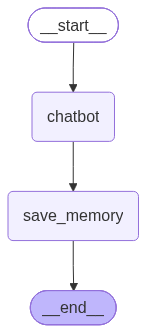

In [38]:
graph

In [39]:
# ============================================================
# CHAT FUNCTION
# ============================================================
def chat(
    user_id,
    thread_id,
    message
):

    config = {

        "configurable": {

            # WHO is the user?
            "user_id": user_id,

            # WHICH conversation?
            "thread_id": thread_id
        }
    }


    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )


    content = result["messages"][-1].content
    return content if isinstance(content, str) else content[0]["text"]

In [40]:
# ============================================================
# TEST
# ============================================================

# ------------------------------------------------------------
# THREAD 1
# ------------------------------------------------------------

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "My favorite programming "
            "language is Python."
        )
    )
)

I have that noted! It's a great choice, especially for the **Agentic RAG application** you are currently building. 

Is there anything specific about your RAG project you'd like to discuss or need help with today?


In [41]:
# ------------------------------------------------------------
# THREAD 1
# ------------------------------------------------------------
print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "I am currently building "
            "an Agentic RAG application."
        )
    )
)


That's right! You're working on an **Agentic RAG application** using **Python**. 

Since you're deep into that project, are you currently focusing on the retrieval logic, the agent's decision-making loop, or perhaps integrating a specific toolset for your agents to use? I'd be happy to help you brainstorm or troubleshoot any part of the architecture.


In [42]:
# ------------------------------------------------------------
# SAME THREAD
# Checkpointer remembers conversation
# ------------------------------------------------------------
print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "What project am I building?"
        )
    )
)

You are building an **Agentic RAG application**.


In [43]:
# ------------------------------------------------------------
# NEW THREAD
# Same user
#
# Thread history is different,
# but SQLite long-term memory is shared.
# ------------------------------------------------------------

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_2",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

You prefer **Python**. It's a great choice for the Agentic RAG application you're currently working on!


In [44]:
# ------------------------------------------------------------
# DIFFERENT USER
# ------------------------------------------------------------
print(
    chat(
        user_id="user_456",
        thread_id="thread_1",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

Your favorite programming language is **Python**.


### 🔬 Complete Persistent Memory Inspector Utility

The helper function below allows inspecting both storage layers directly from SQLite:
- **Short-Term Thread Checkpoints**: Lists saved threads, checkpoint history, and raw SQLite database tuples.
- **Long-Term User Memory**: Queries all extracted facts saved for a given `user_id`.


In [45]:
# ============================================================
# COMPLETE SQLITE PERSISTENT-MEMORY INSPECTOR
# ============================================================

from contextlib import closing
from pathlib import Path
from pprint import pprint

from langchain_core.messages import (
    BaseMessage,
    message_to_dict
)


def _printable(value):
    """Convert LangChain messages and nested values to plain data."""

    if isinstance(value, BaseMessage):
        return message_to_dict(value)

    if isinstance(value, dict):
        return {
            key: _printable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            _printable(item)
            for item in value
        ]

    return value


def _section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_sqlite_details(db_path, row_limit=10):
    """Print schema, columns, row counts, and readable row previews."""

    db_path = Path(db_path).resolve()
    print(f"Database: {db_path}")

    if not db_path.exists():
        print("Database file does not exist yet.")
        return

    with closing(sqlite3.connect(db_path)) as connection:
        connection.row_factory = sqlite3.Row

        tables = connection.execute(
            """
            SELECT name, sql
            FROM sqlite_master
            WHERE type = 'table'
            ORDER BY name
            """
        ).fetchall()

        for table in tables:
            table_name = table["name"]
            safe_table_name = table_name.replace("\"", "\"\"")

            print(f"\nTABLE: {table_name}")
            print("CREATE SQL:")
            print(table["sql"])

            columns = connection.execute(
                f'PRAGMA table_info("{safe_table_name}")'
            ).fetchall()
            print("COLUMNS:")
            pprint([dict(column) for column in columns])

            count = connection.execute(
                f'SELECT COUNT(*) FROM "{safe_table_name}"'
            ).fetchone()[0]
            print(f"ROW COUNT: {count}")

            rows = connection.execute(
                f'SELECT * FROM "{safe_table_name}" LIMIT ?',
                (row_limit,)
            ).fetchall()

            print(f"FIRST {min(row_limit, count)} ROW(S):")
            for row in rows:
                readable_row = {}
                for key in row.keys():
                    value = row[key]
                    if isinstance(value, bytes):
                        value = f"<BLOB: {len(value)} bytes>"
                    readable_row[key] = value
                pprint(readable_row)


def list_persistent_threads():
    """List every thread currently saved by SqliteSaver."""

    _section("ALL PERSISTED CHECKPOINT THREADS")

    try:
        rows = checkpoint_connection.execute(
            """
            SELECT
                thread_id,
                checkpoint_ns,
                COUNT(*) AS checkpoint_count,
                MAX(checkpoint_id) AS latest_checkpoint_id
            FROM checkpoints
            GROUP BY thread_id, checkpoint_ns
            ORDER BY thread_id, checkpoint_ns
            """
        ).fetchall()
    except sqlite3.OperationalError:
        print("No checkpoint table yet. Run chat() at least once.")
        return

    if not rows:
        print("No saved threads found.")
        return

    for row in rows:
        pprint({
            "thread_id": row[0],
            "checkpoint_namespace": row[1],
            "checkpoint_count": row[2],
            "latest_checkpoint_id": row[3]
        })


def inspect_persistent_memory(
    user_id,
    thread_id,
    history_limit=None,
    sqlite_row_limit=10
):
    """Print complete short-term and long-term persistent memory."""

    config = {
        "configurable": {
            "user_id": user_id,
            "thread_id": thread_id
        }
    }

    _section("IDENTITY / MEMORY SCOPE")
    pprint({
        "user_id (long-term scope)": user_id,
        "thread_id (checkpoint scope)": thread_id,
        "checkpoint_database": str(Path("checkpoints.db").resolve()),
        "long_term_database": str(Path(long_term_memory.db_path).resolve())
    })

    _section("CURRENT THREAD STATE - graph.get_state()")
    current_state = graph.get_state(config)
    pprint({
        "values": _printable(current_state.values),
        "next_nodes": current_state.next,
        "config": current_state.config,
        "metadata": current_state.metadata,
        "created_at": current_state.created_at,
        "parent_config": current_state.parent_config,
        "tasks": _printable(current_state.tasks)
    }, sort_dicts=False)

    _section("COMPLETE STATE HISTORY - newest to oldest")
    history = list(
        graph.get_state_history(
            config,
            limit=history_limit
        )
    )
    print(f"Total state snapshots shown: {len(history)}")

    for index, snapshot in enumerate(history, start=1):
        print(f"\n--- STATE SNAPSHOT {index} ---")
        pprint({
            "values": _printable(snapshot.values),
            "next_nodes": snapshot.next,
            "config": snapshot.config,
            "metadata": snapshot.metadata,
            "created_at": snapshot.created_at,
            "parent_config": snapshot.parent_config,
            "tasks": _printable(snapshot.tasks)
        }, sort_dicts=False)

    _section("RAW DECODED CHECKPOINT TUPLES - newest to oldest")
    checkpoint_tuples = list(
        checkpointer.list(
            config,
            limit=history_limit
        )
    )
    print(f"Total checkpoint tuples shown: {len(checkpoint_tuples)}")

    for index, item in enumerate(checkpoint_tuples, start=1):
        print(f"\n--- CHECKPOINT TUPLE {index} ---")
        pprint({
            "config": item.config,
            "checkpoint": _printable(item.checkpoint),
            "metadata": item.metadata,
            "parent_config": item.parent_config,
            "pending_writes": _printable(item.pending_writes)
        }, sort_dicts=False)

    _section("LONG-TERM MEMORY ROWS FOR USER")
    with closing(long_term_memory.connect()) as connection:
        connection.row_factory = sqlite3.Row
        memory_rows = connection.execute(
            """
            SELECT memory_id, user_id, content, created_at
            FROM memories
            WHERE user_id = ?
            ORDER BY created_at, memory_id
            """,
            (user_id,)
        ).fetchall()

    print(f"Total long-term memories: {len(memory_rows)}")
    for row in memory_rows:
        pprint(dict(row), sort_dicts=False)

    _section("CHECKPOINT SQLITE DATABASE DETAILS")
    print_sqlite_details(
        "checkpoints.db",
        row_limit=sqlite_row_limit
    )

    _section("LONG-TERM SQLITE DATABASE DETAILS")
    print_sqlite_details(
        long_term_memory.db_path,
        row_limit=sqlite_row_limit
    )

In [46]:
# First see every thread saved in checkpoints.db
list_persistent_threads()

# Then inspect one thread + one user's long-term memory in full.
# Use history_limit=None for complete history, or e.g. 5 for latest five.
inspect_persistent_memory(
    user_id="sunny_123",
    thread_id="thread_1",
    history_limit=None,
    sqlite_row_limit=10
)


ALL PERSISTED CHECKPOINT THREADS
{'checkpoint_count': 32,
 'checkpoint_namespace': '',
 'latest_checkpoint_id': '1f1b0233-0a46-6f2c-801e-5625db659b33',
 'thread_id': 'thread_1'}
{'checkpoint_count': 8,
 'checkpoint_namespace': '',
 'latest_checkpoint_id': '1f1b0232-dfca-6d19-8006-6fcdb4531fe6',
 'thread_id': 'thread_2'}

IDENTITY / MEMORY SCOPE
{'checkpoint_database': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\04_memory\\checkpoints.db',
 'long_term_database': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\04_memory\\long_term_memory.db',
 'thread_id (checkpoint scope)': 'thread_1',
 'user_id (long-term scope)': 'sunny_123'}

CURRENT THREAD STATE - graph.get_state()
{'values': {'messages': [{'type': 'human',
                          'data': {'content': 'My favorite programming '
                                              'language is Python.',
                                   'additional_kwargs': {},
                                   'res

## 9. LangMem Architecture: Semantic, Episodic & Procedural Memory Taxonomy

**LangMem** provides an advanced classification framework for AI Agent memory systems:

```
                                  LANGMEM ARCHITECTURE
                                           │
          ┌────────────────────────────────┼────────────────────────────────┐
          │                                │                                │
          ▼                                ▼                                ▼
   Long-Term Memory               Short-Term Context               Procedural Learning
  (Cross-Session State)             (Active Session)              (Instruction Tuning)
          │                                │                                │
 ┌────────┴────────┐                       │                       ┌────────┴────────┐
 ▼                 ▼                       ▼                       ▼                 ▼
Semantic        Episodic              Summarization,            Prompt           Multi-Prompt
Facts &         Event                 Checkpointer,             Optimizer        Optimizer
Preferences     Logs                  Message Slicing
```

### LangMem Core Components Breakdown

```
LANGMEM SYSTEM
│
├── 🧠 MEMORY CONTENT
│   ├── Semantic Memory   ──► User profile, facts, preferences, knowledge base
│   ├── Episodic Memory   ──► Event logs, past conversation turn records
│   └── Procedural Memory ──► System prompts, instructions, workflow rules
│
├── ⚡ MEMORY FORMATION
│   ├── Hot Path (In-line) ──► `create_manage_memory_tool`, `create_search_memory_tool`
│   └── Background Sync    ──► `create_memory_manager`, `ReflectionExecutor`
│
├── 💾 STORAGE BACKEND
│   ├── BaseStore          ──► Abstract store interface
│   ├── Namespaces         ──► Hierarchical path isolation per user / domain
│   └── Vector Search      ──► Semantic retrieval over persistent DB
│
└── 🛠️ SHORT-TERM CONTEXT MANAGEMENT
    ├── summarize_messages ──► LLM message compression utility
    └── Checkpointer       ──► Thread state persistence engine
```


### 🔄 End-to-End Execution Flow & Architecture Walkthrough

```
                                     USER
                                      │
                               user_id = sunny_123
                                      │
                   ┌──────────────────┴──────────────────┐
                   │                                     │
                   ▼                                     ▼
              thread_id                              Long-Term
                  │                                    Store
                  ▼                                      │
            Checkpointer                                 │
                  │                                      │
                  ▼                                      ▼
         Current Conversation                   User Preferences & Facts
         (Short-Term Memory)                      (Long-Term Memory)
                  │                                      │
                  └──────────────────┬───────────────────┘
                                     ▼
                                    LLM
                                     │
                                     ▼
                               Generated Answer
                                     │
                                     ▼
                               Memory Manager
                                     │
                                     ▼
                          Extract & Save New Memories
                                     │
                                     ▼
                               Long-Term Store
```

---

### 📝 Step-by-Step Scenario Walkthrough

#### Scenario 1: Thread 1 Interaction
- **Context**: `user_id = sunny_123`, `thread_id = thread_1`
- **User Statement**: *"My favorite programming language is Python."*
- **Execution Flow**:
  1. The user query is processed by the chatbot node.
  2. The `save_memory` node invokes `create_memory_store_manager`.
  3. The LLM evaluates the turn, identifies the long-term fact (*"User prefers Python"*), and writes it to `Store`.
  4. Memory is persisted under namespace `("memories", "sunny_123")`.

#### Scenario 2: Thread 2 Interaction (New Session, Same User)
- **Context**: `user_id = sunny_123`, `thread_id = thread_2`
- **User Query**: *"Which programming language do I prefer?"*
- **Execution Flow**:
  1. The new thread context is isolated by `thread_id = thread_2` (Checkpointer has zero past messages for this thread).
  2. The system executes `memory_manager.search()` using `user_id = sunny_123`.
  3. The Long-Term Store returns *"User prefers Python"*.
  4. The system prompt merges this retrieved fact with the current query and forwards it to the LLM.
  5. **AI Response**: *"You prefer Python!"*

---

### 🎓 4 Core Memory Pillars to Remember

| Concept | Scope | Core Responsibility |
| :--- | :--- | :--- |
| **`Checkpointer`** | Short-Term / Thread | Remembers the active conversation state for a specific thread. |
| **`thread_id`** | Session Scope | Uniquely identifies an individual conversation thread. |
| **`Store`** | Long-Term / Global | Retains facts, preferences, and knowledge across all threads. |
| **`user_id`** | User Scope | Uniquely identifies a user to segregate memories across threads. |
